In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
from tqdm import tqdm
from ekfplot import plot as ek, colors as ec , colorlists
from ekfstats import sampling, functions

from make_punchlines import cmap_dsfs

/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


This is a toy model to describe how different underlying contributors to starbursts will affect the observed merger signal. 

In [3]:
class ToyModel ():
    def __init__ (self, tau_ext=None, s_ext=None, tau_int=None):
        if tau_int is None:
            tau_int = lambda logmstar: 1.
        if tau_ext is None:
            tau_ext = lambda logmstar, xi: xi + 0.5
        if s_ext is None:
            s_ext = lambda logmstar, xi: xi
        #np.where(xi>0.5, 1., 1e-5) #xi + 0.2
        self.pdf_s_internal = lambda s, logmstar: np.exp(-s**2/tau_int(logmstar)**2)
        self.pdf_s_external = lambda s, logmstar, xi: np.exp(-(s-s_ext(logmstar,xi))**2/tau_ext(logmstar, xi)**2)
        
        tau_obs = lambda logmsecondary: 1.
        self.pdf_obs_ms = lambda logmsecondary, xi: np.sqrt(xi) *functions.sigmoid(logmsecondary, 8., 2.)

        self.smf_approx = lambda logmstar: (10.**(logmstar-11.))**-0.41
        
    def sample (self, logmstar, nsamp, f_merger=1.):
        logmstar_sample = np.full(nsamp, logmstar)
        ms_values = sampling.sample_from_pdf((logmstar-2., logmstar), self.smf_approx, nsamp=logmstar_sample.size, is_bounds=True)
        xi_values = 10.**(ms_values-logmstar_sample)
        
        # Pre-compute the grid once
        ngrid = 100  # or less if you can sacrifice some accuracy
        s_grid = np.linspace(0., 4., ngrid)
        xi_grid = np.logspace( np.log10(xi_values.min()), 0., ngrid)

        xi_assns = np.digitize(xi_values, xi_grid, )
        s_values = np.zeros_like(xi_values)
        for xi_idx in np.unique(xi_assns):
            mean_xi = np.mean(xi_values[xi_assns==xi_idx])
            c_pdf = self.pdf_s_external(s_grid, logmstar, mean_xi)
            c_pdf /= c_pdf.sum()
            s_values[xi_assns==xi_idx] = np.random.choice(
                s_grid, 
                p=c_pdf,
                size=(xi_assns==xi_idx).sum(),
                replace=True
            )
        
        # \\ replace 1 - fmerger with internal SFR
        not_interacting = np.random.uniform(0., 1., s_values.size) >= f_merger
        i_pdf = self.pdf_s_internal(s_grid, logmstar)
        i_pdf /= i_pdf.sum()
        s_values[not_interacting] = np.random.choice(
            s_grid,
            p=i_pdf,
            size=not_interacting.sum(),
            replace=True
        )
        
        observed_as_merger = np.random.uniform(0.,1., s_values.size) <= self.pdf_obs_ms(ms_values, xi_values)
        observed_as_merger[not_interacting] = False
        xi_values[not_interacting] = 0.
        
        return logmstar_sample, s_values, xi_values, observed_as_merger

In [4]:
def show_model_results (sample_d, axarr=None, show_legend=False, obs_cut=True):
    if axarr is None:
         fig, axarr = plt.subplots(2, 1,figsize=(5,8))
        
    for lm in mass_keys:
        logmstar_sample, s_values, xi_values, observed_as_merger = sample_d[lm]
        
        if obs_cut:
            smask = s_values < (-5./8.*lm + 8.)
        else:
            smask = np.isfinite(s_values)
        
        
        bin_edges, f_merger, f_merger_ci = sampling.classfraction(
            s_values[smask][observed_as_merger[smask]],
            s_values[smask],
            bins=np.linspace(0.,3.,15)
        )
        
        axarr[0].plot(
            sampling.midpts(bin_edges),
            f_merger,#/f_merger[0],
            #ax=axarr[0],
            color=cmap_dsfs((lm-8.)/2.),
            lw=3,
            label=lm
        )
        axarr[1].plot(
            sampling.midpts(bin_edges),
            f_merger/f_merger[0],
            #ax=axarr[1],
            color=cmap_dsfs((lm-8.)/2.),
            lw=3,
            label=lm
        )   

    if show_legend:
        ek.colorbar_inset(
            cmap_dsfs,
            8.,
            10.,
            x=0.1,
            y=0.9,
            height=0.05,
            width=0.5,
            label=ek.common_labels['logmstar'],
            orientation='horizontal',
            ax=axarr[1]
        )
        
    lkwargs = {'ls':'--', 'color':'lightgrey', 'zorder':-1}
    axarr[1].axhline(1., **lkwargs)    
    axarr[1].axvline(0., **lkwargs )
    for ax in axarr:
        ax.set_xlabel(r'$ \mathcal{S} = \frac{\log_{10}[{\rm SFR}/{\rm SFS(M_\bigstar)}]}{\sigma_{\rm SFS}}$', fontsize=20)
    axarr[0].set_ylabel(r'$\langle \rm Pr[TF] \rangle$')
    axarr[1].set_ylabel(r'$\mathcal{R}_{\rm int}(\mathcal{S})$', labelpad=-8)   
    

In [5]:
def show_model_setup(tm, axarr=None, internal_legend=False, external_legend=False, show_pobs=False):
    if axarr is None:
        fig, axarr = plt.subplots(2,1,figsize=(5,8))
    lkwargs = {'lw':3}
    cc=ec.ColorBase(colorlists.slides['red']).modulate(0.2,-0.6)
    bc=ec.ColorBase(colorlists.slides['blue']).modulate(0.2,-0.6)
    
    s_grid = np.linspace(0., 3., 100)

    axarr[0].plot(
        s_grid,
        tm.pdf_s_external(s_grid, 9.5,0.1),
        label=external_legend and r'Pr[$\mathcal{S}|M_\bigstar,0.1$]' or None,
        color=cc.modulate(-0.1,0.2).base,
        ls='-',
        **lkwargs
    )    
    axarr[0].plot(
        s_grid,
        tm.pdf_s_external(s_grid, 9.5, 1.),
        label=external_legend and r'Pr[$\mathcal{S}|M_\bigstar,1$]' or None,
        color=cc.modulate(0.2).base,
        ls='-',
        **lkwargs
    )
    axarr[0].plot(
        s_grid,
        tm.pdf_s_external(s_grid, 9.5,0.5),
        label=external_legend and r'Pr[$\mathcal{S}|M_\bigstar,0.5$]' or None,
        color=cc.modulate(-0.05, 0.1).base,
        ls='-',
        **lkwargs
    )    
   
    axarr[0].plot(
        s_grid,
        tm.pdf_s_internal(s_grid, 9.5),
        label=internal_legend and r'Pr$_{\rm  i}[\mathcal{S}|10^{9.5}$]' or None,
        color=bc.modulate(-0.1,0.1).base,
        **lkwargs
    )
    axarr[0].plot(
        s_grid,
        tm.pdf_s_internal(s_grid, 8.5),
        label=internal_legend and r'Pr$[\mathcal{S}|10^{8.5}$]' or None,
        ls='--',
        color=bc.modulate(0.).base,
        **lkwargs
    )
    axarr[0].plot(
        s_grid,
        tm.pdf_s_internal(s_grid, 8.),
        label=internal_legend and r'Pr$[\mathcal{S}|10^{8}$]' or None,
        color=bc.modulate(0.1).base,
        ls=':',
        **lkwargs
    )    
    axarr[0].plot(
        s_grid,
        tm.pdf_s_internal(s_grid, 10.),
        label=internal_legend and r'Pr$_{\rm  i}[\mathcal{S}|10^{10}$]' or None,
        color=bc.modulate(-0.2,0.2).base,
        **lkwargs
    ) 

    
    if show_pobs:
        msgrid = np.linspace(7., 10., 100)
        axarr[1].plot(
            msgrid,
            tm.pdf_obs_ms(msgrid, 1.),
            color=cc.modulate(0.2).base,
            **lkwargs
        )
        axarr[1].plot(
            msgrid,
            tm.pdf_obs_ms(msgrid, 0.5),
            color=cc.modulate(-0.05, 0.1).base,
            **lkwargs
        )    
        axarr[1].plot(
            msgrid,
            tm.pdf_obs_ms(msgrid, 0.1),
            color=cc.modulate(-0.1,0.2).base,
            **lkwargs
        )    

    if external_legend or internal_legend:
        axarr[0].legend(
            loc = external_legend and 'upper right' or 'best', 
            fontsize=12,
            title=external_legend and 'External bursts' or 'Internal bursts'
        )
    #axarr[0].set_xlabel(r'$\mathcal{S}$')
    axarr[0].set_ylabel(r'Pr[$\mathcal{S}|M_\bigstar,\xi$]')
    axarr[0].set_xlabel(r'$ \mathcal{S} = \frac{\log_{10}[{\rm SFR}/{\rm SFS(M_\bigstar)}]}{\sigma_{\rm SFS}}$', fontsize=20)
    #axarr[1].set_ylabel(r'Pr[$\mathcal{O}|M_s$]') 

In [15]:
fn = lambda logmstar, xi: np.sqrt(0.5*xi)

models = [
    #ToyModel(tau_ext = lambda logmstar, xi: 3., s_ext=lambda logmstar, xi: 0., tau_int=lambda logmstar: 3.  ),
    ToyModel(tau_ext = lambda logmstar, xi: 0.75, s_ext=lambda logmstar, xi: 0., tau_int=lambda logmstar: .75),
    ToyModel(tau_ext = lambda logmstar, xi: 0.75, s_ext=lambda logmstar, xi: 0.75, tau_int=lambda logmstar: .75),
    #ToyModel(tau_ext = lambda logmstar, xi: 1., s_ext=lambda logmstar, xi: 0., tau_int=lambda logmstar: (10.1-logmstar)*0.75),
    ToyModel(tau_ext = lambda logmstar, xi: 1., s_ext=fn, tau_int=lambda logmstar: 0.75  ),
    ToyModel(tau_ext = lambda logmstar, xi: 1., s_ext=fn, tau_int=lambda logmstar: (10.1-logmstar)*0.4)
]
model_d = {}
tags = ['flat','a0','data','int']
for idx,tm in enumerate(models):
    sample_d = {}
    mass_keys = np.arange(8., 10., 0.25)
    for lm in mass_keys:
        sample_d[lm] = tm.sample(lm, 3_000_000, f_merger=0.5)    
    model_d[tags[idx]] = tm, sample_d

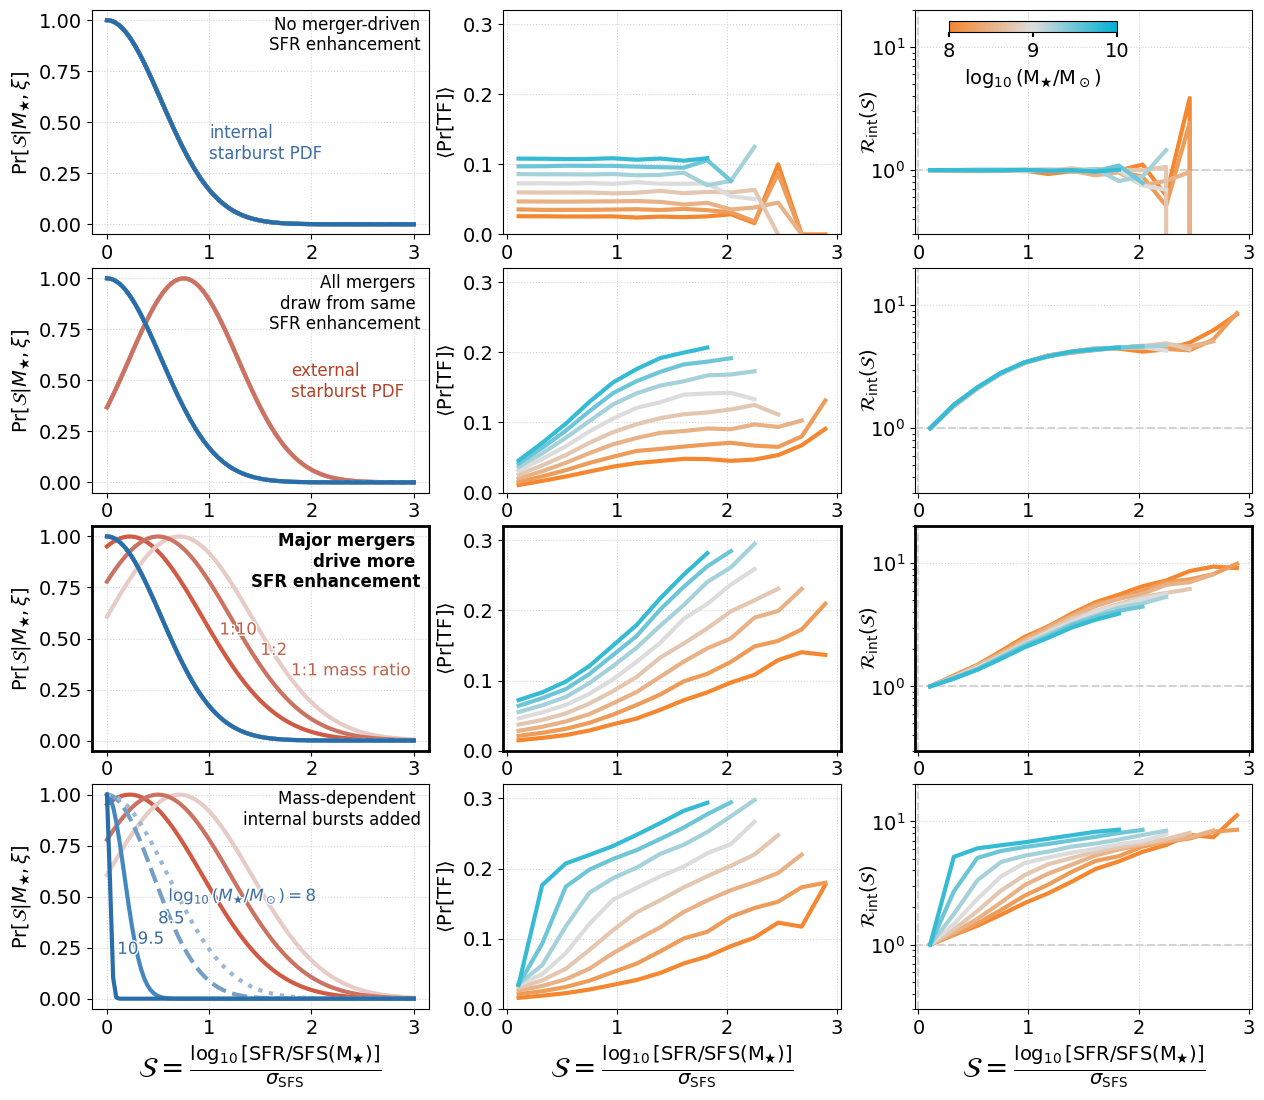

In [16]:
scale = 0.85
fig, axarr = plt.subplots(4,3,figsize=(15*scale,11.*4./3.*.9*scale))

for idx,tag in enumerate(tags):
    tm, sample_d = model_d[tag]
    show_model_results(sample_d, axarr=axarr[idx,1:], show_legend=idx==0 )
    show_model_setup(tm, axarr=axarr[idx,:1], )
    axarr[idx,2].set_yscale('log')
    axarr[idx,2].set_ylim(0.3, 20.)
    axarr[idx,1].set_ylim(0., 0.32)
    axarr[idx,1].set_yticks([0., 0.1, 0.2, 0.3])

# \\ clean up
for ax in axarr[:3].flatten():
    ax.set_xlabel(None)

for ax in axarr.flatten():
    ax.grid(ls=':', color='lightgrey')

for ax in axarr[2]:
    #ax.xaxis.get_label().set_fontweight('bold')
    #ax.yaxis.get_label().set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.subplots_adjust(wspace=0.22,hspace=0.15)

subtitles = [
    f'''No merger-driven
SFR enhancement''',
    f'''All mergers 
draw from same 
SFR enhancement''',
    f'''Major mergers 
drive more 
SFR enhancement''',
    f'''Mass-dependent 
internal bursts added'''
]
for idx,ax in enumerate(axarr[:,0]):
    ek.text(
        0.975, 
        0.975, 
        subtitles[idx],
        ax=ax,
        fontsize=12,
        fontweight=idx==2 and 'bold' or 'normal'
    )

ek.text(
    1.,
    0.3,
    f'''internal
starburst PDF''',
    color='#3D6DA4',
    ax=axarr[0,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
)

ek.text(
    1.8,
    0.4,
    f'''external
starburst PDF''',
    color='#B14328',
    ax=axarr[1,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
)


ek.text(
    1.1,
    0.5,
    f'''1:10''',
    color='#C2614A',
    ax=axarr[2,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
ek.text(
    1.5,
    0.4,
    f'''1:2''',
    color='#C2614A',
    ax=axarr[2,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
ek.text(
    1.8,
    0.3,
    f'''1:1 mass ratio''',
    color='#C2614A',
    ax=axarr[2,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)

ek.text(
    0.1,
    0.2,
    f'''10''',
    color='#3D6DA4',
    ax=axarr[3,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
ek.text(
    0.3,
    0.25,
    f'''9.5''',
    color='#3D6DA4',
    ax=axarr[3,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
ek.text(
    0.5,
    0.35,
    f'''8.5''',
    color='#3D6DA4',
    ax=axarr[3,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
ek.text(
    0.6,
    0.45,
    rf'''$\log_{{10}}(M_\bigstar/M_\odot)=8$''',
    color='#3D6DA4',
    ax=axarr[3,0],
    fontsize=12,
    coord_type='absolute',
    ha='left',
    bordercolor='w',
    borderwidth=2
)
if True:
    plt.savefig('/Users/kadofong/work/papers/journal/MerianStarbursts/figures/toymodel.pdf')

TypeError: ToyModel.__init__.<locals>.<lambda>() missing 1 required positional argument: 'xi'

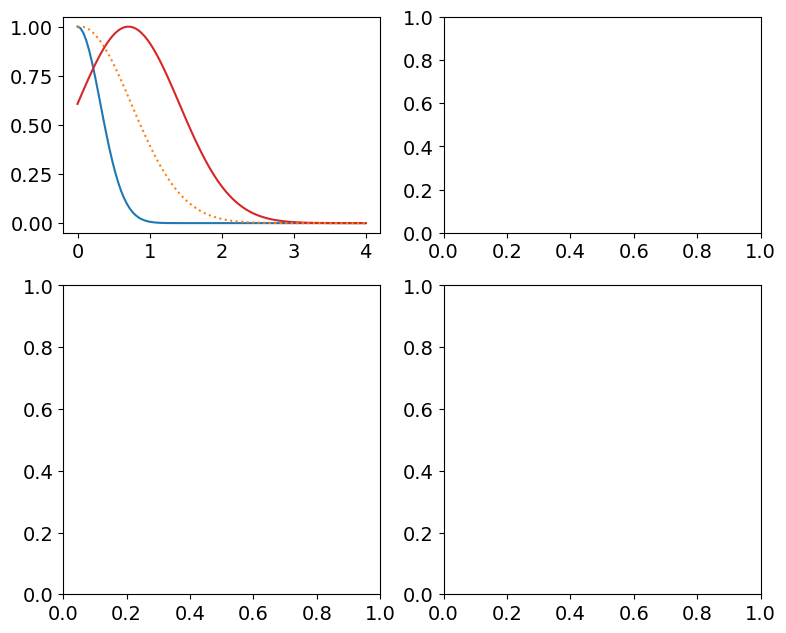

In [1454]:
fig, f_axarr = plt.subplots(2,2,figsize=(12*.75, 10*.75), gridspec_kw={'height_ratios':(0.7,1.)})

axarr = f_axarr[0]
s_grid = np.linspace(0., 4, 100)
axarr[0].plot(
    s_grid,
    tm.pdf_s_internal(s_grid, 9.5),
    label='internal'
)
axarr[0].plot(
    s_grid,
    tm.pdf_s_external(s_grid, 9.5, 1.),
    label=r'$\xi=1$',
    color='C3'
)
axarr[0].plot(
    s_grid,
    tm.pdf_s_external(s_grid, 9.5, 1e7/(10.**9.5)),
    label= rf'$\xi={1e7/(10.**9.5):.2e}$',
    color='C1',
    ls=':'
)


msgrid = np.linspace(6., 10., 100)
axarr[1].plot(
    msgrid,
    tm.pdf_obs_ms(msgrid)
)
axarr[1].scatter(
    7.,
    tm.pdf_obs_ms(7.),
    color='C1'
)
axarr[1].scatter(
    9.5,
    tm.pdf_obs_ms(9.5),
    color='C3'
)

axarr[0].legend()
axarr[0].set_xlabel(r'$\mathcal{S}$')
axarr[0].set_ylabel(r'Pr[$\mathcal{S}|M_\bigstar,\xi$]')
axarr[1].set_xlabel(ek.common_labels['logmstar'])
axarr[1].set_ylabel(r'Pr[$\mathcal{O}|M_s$]')

axarr = f_axarr[1]
for lm in mass_keys:
    logmstar_sample, s_values, xi_values, observed_as_merger = sample_d[lm]
    
    bin_edges, f_merger, f_merger_ci = sampling.classfraction(
        s_values[observed_as_merger],
        s_values,
        bins=np.linspace(0.,4.,15)
    )
    
    ek.outlined_plot(
        sampling.midpts(bin_edges),
        f_merger,#/f_merger[0],
        ax=axarr[0],
        color=cmap((lm-7.)/3.),
        lw=2,
        label=lm
    )
    ek.outlined_plot(
        sampling.midpts(bin_edges),
        f_merger/f_merger[0],
        ax=axarr[1],
        color=cmap((lm-7.)/3.),
        lw=2,
        label=lm
    )   

ek.colorbar_inset(
    cmap,
    7.,
    10.,
    x=0.75,
    y=0.35,
    height=0.6,
    width=0.05,
    label=ek.common_labels['logmstar'],
    orientation='vertical',
    ax=axarr[0]
)

lkwargs = {'ls':':', 'color':'lightgrey', 'zorder':-1}
axarr[1].axhline(1., **lkwargs)    
axarr[1].axvline(0., **lkwargs )
for ax in axarr:
    ax.set_xlabel(r'$ \mathcal{S} = \frac{\log_{10}[{\rm SFR}/{\rm SFS(M_\bigstar)}]}{\sigma_{\rm SFS}}$', fontsize=20)
axarr[0].set_ylabel(r'$\langle \rm Pr[interaction] \rangle$')
axarr[1].set_ylabel(r'$\mathcal{R}_{\rm int}(\mathcal{S})$')
#axarr[1].set_ylim(0.5, axarr[1].get_ylim()[-1])
#axarr[1].set_yscale('log')
plt.tight_layout ()